# NLP Disaster Tweets Kaggle Mini-Project

# Problem/Data

#### Citation: Kaggle - https://www.kaggle.com/c/nlp-getting-started/overview

Problem  
Twitter has become an important communication channel in times of emergency. The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).  
But, it’s not always clear whether a person’s words are actually announcing a disaster.
In this competition, you’re challenged to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t. You’ll have access to a dataset of 10,000 tweets that were hand classified. If this is your first time working on an NLP problem, we've created a quick tutorial to get you up and running.

Files needed
- Download Link: https://www.kaggle.com/competitions/nlp-getting-started/data
- You'll need train.csv, test.csv and sample_submission.csv.

Dataset  
Each sample in the train and test set has the following information:
 - The text of a tweet
 - A keyword from that tweet (although this may be blank!)
 - The location the tweet was sent from (may also be blank)

Columns
- id - a unique identifier for each tweet
- text - the text of the tweet
- location - the location the tweet was sent from (may be blank)
- keyword - a particular keyword from the tweet (may be blank)
- target - in train.csv only, this denotes whether a tweet is about a real disaster (1) or not (0)

Prediction
- You are predicting whether a given tweet is about a real disaster or not. If so, predict a 1. If not, predict a 0.
  
Submission
- Submission File
For each ID in the test set, you must predict 1 if the tweet is describing a real disaster, and 0 otherwise.   

Evaluation
- Submissions are evaluated using F1 between the predicted and expected answers.

# Plan
- Download and extract the files from Kaggle (see above)
- Download, extract and copy GloVe (see below)
- Import libraries
- Load the data
- EDA
- Data preprocessing
- Tokenization
- Word embeddings (GloVe)
- Baseline LSTM model
- Tuned LSTM model (Hyperparameter Tuning)
- GRU model
- Stacked GRU model
- Model comparison
- Conclusions
- Discussion
- Link GitHub repository
- Citation
- AI Acknowledgement

# Q/A and Explanations
- Why using LSTM models:
  - They capture long-range dependencies effectively, which helps when tweets contain context spread across the sequence.
- Why using GRU models:
  - They train faster and use fewer parameters.
  - GRUs often generalize better on smaller datasets.
  - A Stacked GRU model to add a GRU layer for capturing deeper temporal patterns.
- Why using GloVe for Twitter:
  - These embeddings are trained on a massive corpus of real Twitter data, capturing slang, abbreviations, and platform-specific language.
- Why retrain all models on full training data:
  - To let each model learn from the maximum available data, improving its final predictive performance.

# Download GloVe Twitter from Stanford NLP Official Download
- Download Link: https://nlp.stanford.edu/data/glove.twitter.27B.zip
- The file has about 3.6 GB.
- Extract the Zip file.
- Copy glove.twitter.27B.200d.txt (1.4 GB) in the directory of this Notebook (or adjust GLOVE_PATH in Word Embedding accordingly).

# Notebook
- Import Libraries
- Set configuration data

In [8]:
import os
import re
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Bidirectional, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Load the data

In [10]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)


# EDA

target
0    4342
1    3271
Name: count, dtype: int64


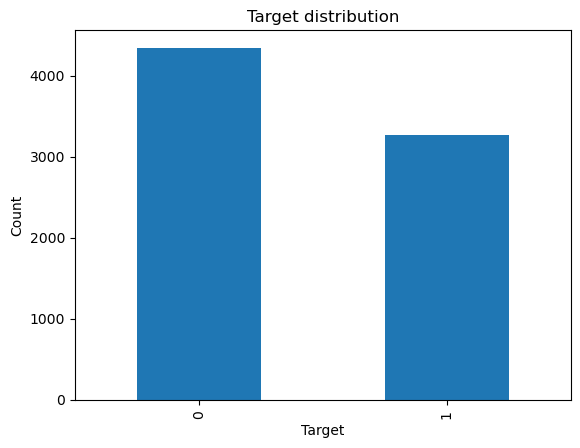


Examples for target = 0:


15      What's up man?
16       I love fruits
17    Summer is lovely
Name: text, dtype: object


Examples for target = 1:


0    Our Deeds are the Reason of this #earthquake M...
1               Forest fire near La Ronge Sask. Canada
2    All residents asked to 'shelter in place' are ...
Name: text, dtype: object

In [12]:
# Check distribution
print(train_df['target'].value_counts())
train_df['target'].value_counts().plot(kind='bar')
plt.title("Target distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# Show a few example tweets
for label in [0, 1]:
    print(f"\nExamples for target = {label}:")
    display(train_df[train_df['target'] == label]['text'].head(3))

In [13]:
# Show columns/dtypes
train_df.info()
print ("\n")

# Check for missing values
print ("Missing Values:")
train_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


Missing Values:


id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

##### Missing values: keyword and location are optional fields in the original tweets, so missing values are expected noise rather than data errors.

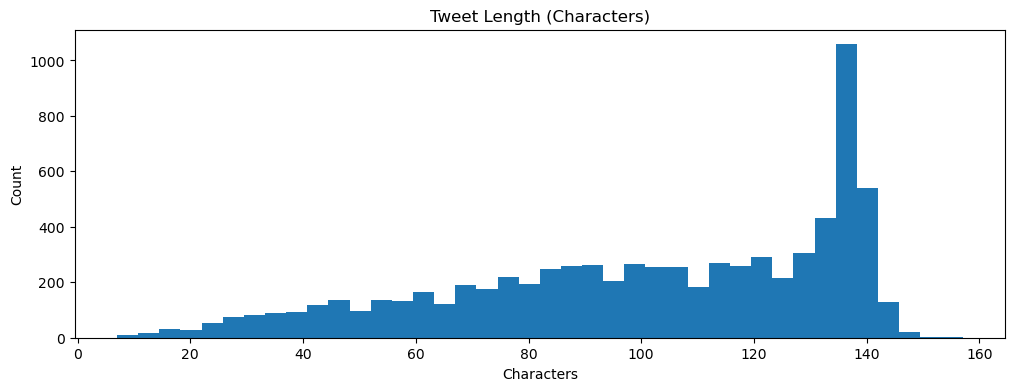

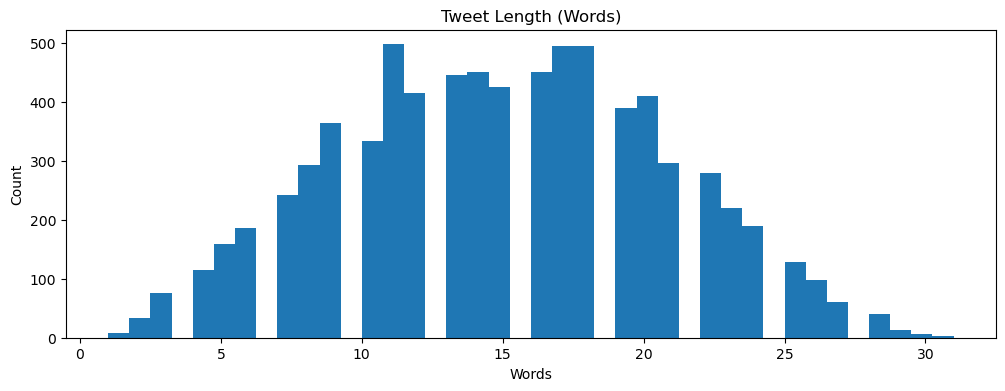

In [15]:
# Show tweet Length
# Character length
train_df["char_len"] = train_df["text"].str.len()
# Word length
train_df["word_len"] = train_df["text"].str.split().str.len()

# Histograms
plt.figure(figsize=(12,4))
plt.hist(train_df["char_len"], bins=40)
plt.title("Tweet Length (Characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,4))
plt.hist(train_df["word_len"], bins=40)
plt.title("Tweet Length (Words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

##### This helps to set the Hyperparameter: 50 tokens is a safe sequence cap, and vocabulary distribution confirms that 20k words covers the dataset well (MAX_VOCAB_SIZE = 20000 and MAX_SEQUENCE_LENGTH = 50).

## Data/Text preprocessing

In [18]:
URL_PATTERN = r'https?://\S+|www\.\S+'
HTML_PATTERN = r'<.*?>'
MENTION_PATTERN = r'@[A-Za-z0-9_]+'

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(URL_PATTERN, ' url ', text)
    # Remove HTML tags
    text = re.sub(HTML_PATTERN, ' ', text)
    # Replace mentions with token
    text = re.sub(MENTION_PATTERN, ' user ', text)
    # Remove non-alphabetic characters (keep basic punctuation)
    text = re.sub(r"[^a-zA-Z!?\s]", " ", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].astype(str).apply(clean_text)
test_df["clean_text"] = test_df["text"].astype(str).apply(clean_text)
train_df[["text", "clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


## Tokenization and padding

In [20]:
# Hyperparameter
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 50  

# Fit tokenizer
all_text = pd.concat([train_df["clean_text"], test_df["clean_text"]])
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(all_text)

# Convert text to sequences
X = tokenizer.texts_to_sequences(train_df["clean_text"])
X_test = tokenizer.texts_to_sequences(test_df["clean_text"])

# Pad sequences
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test = pad_sequences(X_test, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
y = train_df["target"].values

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (7613, 50)
X_test shape: (3263, 50)


## Word embedding

In [22]:
GLOVE_PATH = "glove.twitter.27B.200d.txt"

EMBEDDING_DIM = 200  # must match the dimension of the GloVe file

print("Loading GloVe Twitter embeddings from:", GLOVE_PATH)
embeddings_index = {}

with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.rstrip().split(" ")
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Found %d word vectors." % len(embeddings_index))

word_index = tokenizer.word_index

# Limit to MAX_VOCAB_SIZE and add 1 for padding index 0
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM), dtype="float32")

for word, i in word_index.items():
    if i >= num_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector  # words not found remain zeros

print("Embedding matrix shape:", embedding_matrix.shape)

Loading GloVe Twitter embeddings from: glove.twitter.27B.200d.txt
Found 1193514 word vectors.
Embedding matrix shape: (17185, 200)


# Baseline LSTM Model

In [24]:
### Function for plotting the train curves
def plot_training_history(history):
    history_dict = history.history
    epochs_range = range(1, len(history_dict["loss"]) + 1)
    plt.figure()
    plt.plot(epochs_range, history_dict["loss"], label="Training loss")
    plt.plot(epochs_range, history_dict["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.show()

    plt.figure()
    plt.plot(epochs_range, history_dict["accuracy"], label="Training accuracy")
    plt.plot(epochs_range, history_dict["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.show()

### Train/validation split

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_SEED, stratify=y
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((6851, 50), (762, 50), (6851,), (762,))

### Build the LSTM model / Baseline Model

In [28]:
modelbl=Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(num_words,EMBEDDING_DIM,weights=[embedding_matrix],trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])
modelbl.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(1e-4),metrics=['accuracy'])
modelbl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 50, 200)             │       3,437,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │         135,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,581,001 (13.66 MB)

 Trainable params: 144,001 (562.50 KB)

 Non-trainable params: 3,437,000 (13.11 MB)

### Train the model / Baseline Model

In [30]:
BATCH_SIZE = 64
EPOCHS = 6

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

historybl = modelbl.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6184 - loss: 0.6596 - val_accuracy: 0.7126 - val_loss: 0.6164
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7529 - loss: 0.5316 - val_accuracy: 0.8005 - val_loss: 0.4522
Epoch 3/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8051 - loss: 0.4581 - val_accuracy: 0.8123 - val_loss: 0.4350
Epoch 4/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8183 - loss: 0.4338 - val_accuracy: 0.8163 - val_loss: 0.4305
Epoch 5/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8209 - loss: 0.4253 - val_accuracy: 0.8150 - val_loss: 0.4319
Epoch 6/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8262 - loss: 0.4188 - val_accuracy: 0.8136 - val_loss: 0.4307


### Training curves

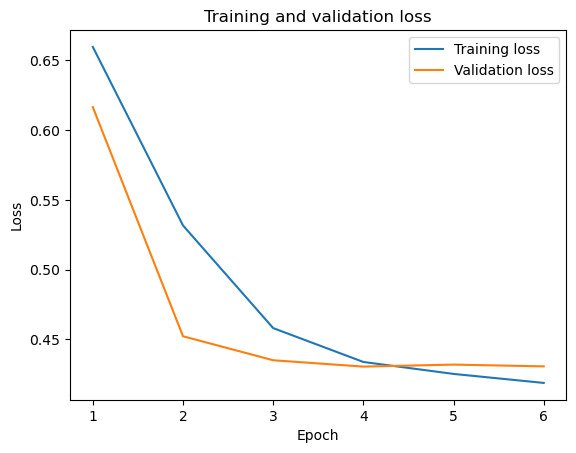

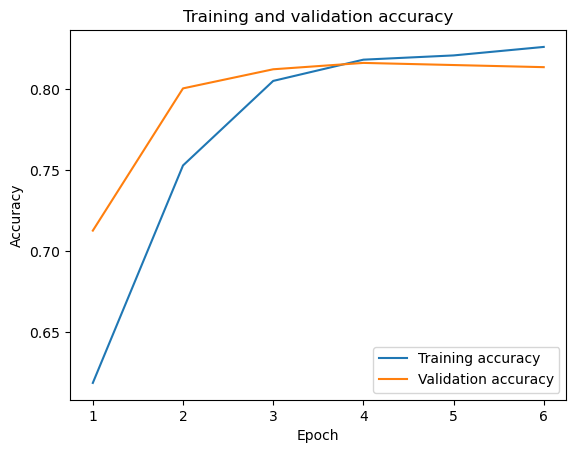

In [32]:
plot_training_history(historybl)

### Evaluation on validation set

In [34]:
val_preds = (modelbl.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, val_preds))
cm = confusion_matrix(y_val, val_preds)
print("Confusion matrix: LSTM Baseline\n", cm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       435
           1       0.83      0.72      0.77       327

    accuracy                           0.82       762
   macro avg       0.82      0.80      0.81       762
weighted avg       0.82      0.82      0.81       762

Confusion matrix: LSTM Baseline
 [[387  48]
 [ 92 235]]


### Retrain on full training data

In [36]:
historyblfull = modelbl.fit(
     X, y,
     epochs=EPOCHS,
     batch_size=BATCH_SIZE,
     verbose=1
 )

Epoch 1/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8225 - loss: 0.4238
Epoch 2/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8224 - loss: 0.4192
Epoch 3/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8278 - loss: 0.4145
Epoch 4/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8311 - loss: 0.4060
Epoch 5/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8296 - loss: 0.4032
Epoch 6/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8357 - loss: 0.3983


### Predict on test set and create submission

In [38]:
test_preds = (modelbl.predict(X_test) > 0.5).astype(int).ravel()

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": test_preds
})

submission_path = "lstm_submission-baseline.csv"
submission.to_csv(submission_path, index=False)
submission.head()

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


### Kaggle Score LSTM Baseline
Public Score: 0.80723

In [40]:
# Save Kaggle score for comparison
kaggle_baseline = 0.80723

# Hyperparameter Tuning LSTM Model
- Set learning Rate to 5e-5

### Build the LSTM Model (Hyperparameter Tuning)

In [43]:
modelht=Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(num_words,EMBEDDING_DIM,weights=[embedding_matrix],trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])
modelht.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(5e-5),metrics=['accuracy'])
modelht.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 50, 200)             │       3,437,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         135,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,581,001 (13.66 MB)

 Trainable params: 144,001 (562.50 KB)

 Non-trainable params: 3,437,000 (13.11 MB)

### Train the Model

In [45]:
BATCH_SIZE = 64
EPOCHS = 6

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

historyht = modelht.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5796 - loss: 0.6741 - val_accuracy: 0.6155 - val_loss: 0.6483
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6476 - loss: 0.6437 - val_accuracy: 0.7192 - val_loss: 0.6093
Epoch 3/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7269 - loss: 0.5752 - val_accuracy: 0.7927 - val_loss: 0.4805
Epoch 4/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7787 - loss: 0.4972 - val_accuracy: 0.8110 - val_loss: 0.4496
Epoch 5/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7957 - loss: 0.4694 - val_accuracy: 0.8136 - val_loss: 0.4379
Epoch 6/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8028 - loss: 0.4550 - val_accuracy: 0.8110 - val_loss: 0.4340


### Training curves

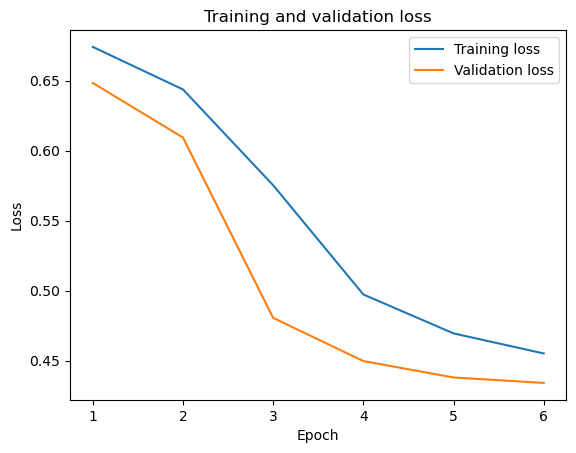

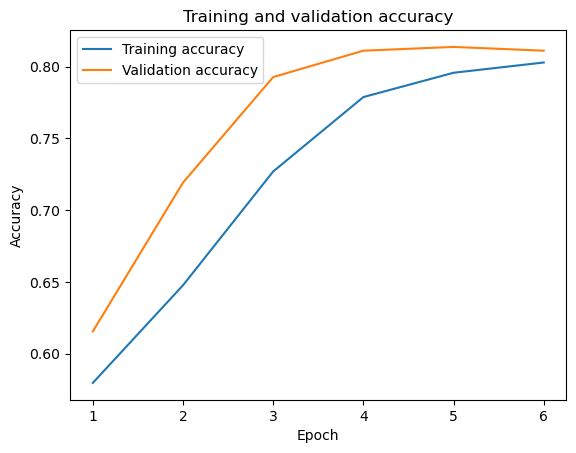

In [47]:
plot_training_history(historyht)

### Evaluation on validation set

In [49]:
val_preds = (modelht.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, val_preds))
cm = confusion_matrix(y_val, val_preds)
print("Confusion matrix: LTSM Hyperparameter Tuning\n", cm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       435
           1       0.81      0.74      0.77       327

    accuracy                           0.81       762
   macro avg       0.81      0.80      0.80       762
weighted avg       0.81      0.81      0.81       762

Confusion matrix: LTSM Hyperparameter Tuning
 [[377  58]
 [ 86 241]]


### Retrain on full training data

In [51]:
historyhtfull = modelht.fit(
     X, y,
     epochs=EPOCHS,
     batch_size=BATCH_SIZE,
     verbose=1
 )

Epoch 1/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8114 - loss: 0.4429
Epoch 2/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8115 - loss: 0.4355
Epoch 3/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8147 - loss: 0.4260
Epoch 4/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8214 - loss: 0.4197
Epoch 5/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8211 - loss: 0.4153
Epoch 6/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8252 - loss: 0.4122


### Predict on test set and create submission

In [53]:
test_preds = (modelht.predict(X_test) > 0.5).astype(int).ravel()

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": test_preds
})

submission_path = "lstm_submission-tuned.csv"
submission.to_csv(submission_path, index=False)
submission.head()

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


### Kaggle Score LSTM Tuned
Public Score: 0.80968

In [55]:
# Save Kaggle score for comparison
kaggle_tuned = 0.80968

# GRU Models

## GRU Model

In [58]:
gru_model=Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(num_words,EMBEDDING_DIM,weights=[embedding_matrix],trainable=True),
    Bidirectional(GRU(64)),
    Dropout(0.4),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])
gru_model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(5e-4),metrics=['accuracy'])
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 50, 200)             │       3,437,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 128)                 │         102,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,547,465 (13.53 MB)

 Trainable params: 3,547,465 (13.53 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [60]:
# Train GRU model
gru_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=gru_callbacks,
    verbose=1
)

Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6733 - loss: 0.5976 - val_accuracy: 0.7835 - val_loss: 0.4670
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8097 - loss: 0.4407 - val_accuracy: 0.8189 - val_loss: 0.4144
Epoch 3/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8456 - loss: 0.3699 - val_accuracy: 0.8268 - val_loss: 0.4184
Epoch 4/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8761 - loss: 0.3202 - val_accuracy: 0.8163 - val_loss: 0.4399


### Training curves

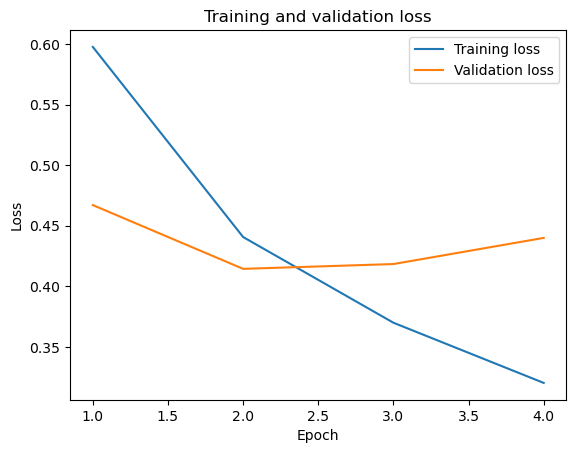

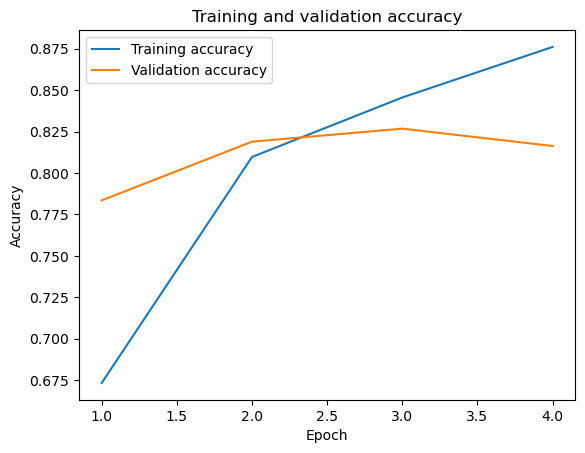

In [62]:
plot_training_history(gru_history)

### Evaluation on validation set

In [64]:
# Evaluation of GRU model on validation set
gru_val_preds = (gru_model.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, gru_val_preds))
gru_cm = confusion_matrix(y_val, gru_val_preds)
print("Confusion matrix GRU:\n", gru_cm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       435
           1       0.81      0.75      0.78       327

    accuracy                           0.82       762
   macro avg       0.82      0.81      0.81       762
weighted avg       0.82      0.82      0.82       762

Confusion matrix GRU:
 [[378  57]
 [ 81 246]]


### Retrain on full training data

In [66]:
historygru = gru_model.fit(
     X, y,
     epochs=EPOCHS,
     batch_size=BATCH_SIZE,
     verbose=1
 )

Epoch 1/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8457 - loss: 0.3759
Epoch 2/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8722 - loss: 0.3280
Epoch 3/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8920 - loss: 0.2805
Epoch 4/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9141 - loss: 0.2349
Epoch 5/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9331 - loss: 0.1860
Epoch 6/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9490 - loss: 0.1482


### Predict on test set and create submission

In [68]:
# Create submission file using GRU model predictions on the test set
gru_test_preds = (gru_model.predict(X_test) > 0.5).astype(int).ravel()

submission_gru = pd.DataFrame({
    "id": test_df["id"],
    "target": gru_test_preds
})

submission_gru_path = "gru_submission.csv"
submission_gru.to_csv(submission_gru_path, index=False)
submission_gru.head()

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


### Kaggle Score GRU Model
Public Score: 0.80110

In [70]:
# Save Kaggle score for comparison
kaggle_gru = 0.80110

## Stacked GRU Model

In [72]:
# Stacked GRU model
stacked_gru_model=Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(num_words,EMBEDDING_DIM,weights=[embedding_matrix],trainable=True),
    Bidirectional(GRU(64,return_sequences=True,dropout=0.3,recurrent_dropout=0.3)),
    Bidirectional(GRU(32,dropout=0.3,recurrent_dropout=0.3)),
    Dropout(0.4),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])
stacked_gru_model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(5e-4),metrics=['accuracy'])
stacked_gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 200)             │       3,437,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 50, 128)             │         102,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,574,473 (13.64 MB)

 Trainable params: 3,574,473 (13.64 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [74]:
stacked_gru_history = stacked_gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=gru_callbacks,   
    verbose=1
)

Epoch 1/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.6692 - loss: 0.6086 - val_accuracy: 0.7690 - val_loss: 0.4932
Epoch 2/6
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.7822 - loss: 0.4856 - val_accuracy: 0.8110 - val_loss: 0.4302


### Training curves

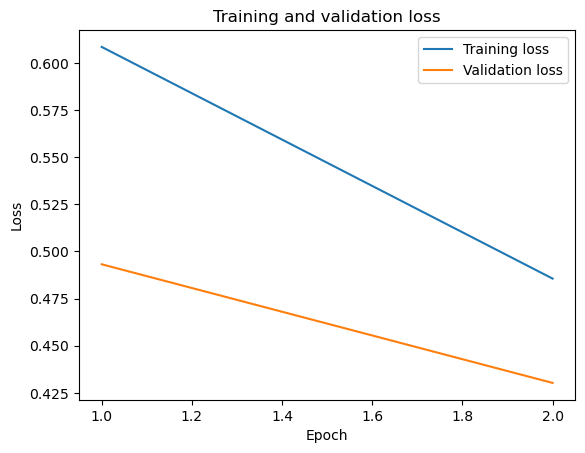

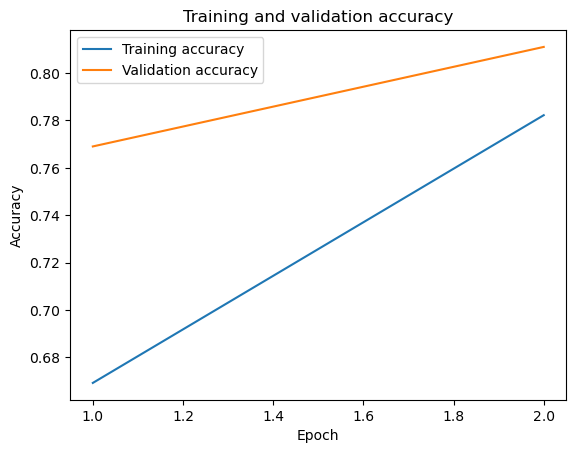

In [76]:
plot_training_history(stacked_gru_history)

### Evaluation on validation set

In [78]:
stacked_gru_val_preds = (stacked_gru_model.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, stacked_gru_val_preds))

stacked_gru_cm = confusion_matrix(y_val, stacked_gru_val_preds)
print("Confusion matrix stacked GRU:\n", stacked_gru_cm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       435
           1       0.75      0.70      0.72       327

    accuracy                           0.77       762
   macro avg       0.77      0.76      0.76       762
weighted avg       0.77      0.77      0.77       762

Confusion matrix stacked GRU:
 [[358  77]
 [ 99 228]]


### Retrain on full training data

In [80]:
historystgru = stacked_gru_model.fit(
     X, y,
     epochs=EPOCHS,
     batch_size=BATCH_SIZE,
     verbose=1
 )

Epoch 1/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7751 - loss: 0.4942
Epoch 2/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8148 - loss: 0.4390
Epoch 3/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8348 - loss: 0.3954
Epoch 4/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8558 - loss: 0.3567
Epoch 5/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8686 - loss: 0.3319
Epoch 6/6
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8840 - loss: 0.2994


### Predict on test set and create submission

In [82]:
stacked_gru_test_preds = (stacked_gru_model.predict(X_test) > 0.5).astype(int).ravel()

submission_stacked_gru = pd.DataFrame({
    "id": test_df["id"],
    "target": stacked_gru_test_preds
})

submission_stacked_gru.to_csv("stacked_gru_submission.csv", index=False)
submission_gru.head()

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


### Kaggle Score Stacked GRU
Public Score: 0.81918

In [84]:
# Save Kaggle score for comparison
kaggle_grustacked = 0.81918

# Compare Models

In [86]:
scores = [
    ("LSTM Baseline", kaggle_baseline),  
    ("LSTM Tuned", kaggle_tuned),   
    ("GRU", kaggle_gru),   
    ("Stacked GRU", kaggle_grustacked),   ]

kaggle_scores = pd.DataFrame(scores, columns=["Model", "Public Score"])
kaggle_scores.sort_values("Public Score", ascending=False).reset_index(drop=True)

,Model,Public Score
0,Stacked GRU,0.81918
1,LSTM Tuned,0.80968
2,LSTM Baseline,0.80723
3,GRU,0.80110


# Conclusions
- The Stacked GRU model shows the best performance.
- LSTM with Hyperparameter Tuning is the second best model.
- All models used the same preprocessing pipeline, so the score differences mainly reflect architectural and hyperparameter choices.
- Overall, pretrained GloVe Twitter embeddings combined with recurrent architectures can achieve competitive performance on the Disaster Tweets task.

# Discussion
- Further Hyperparameter Tuning with different Batch Sizes and more Epochs
- Use BiLSTM
- Use Transformers (BERT)
- Use other GloVe pretrained models from the downloaded zip-file

## Link GitHub Repository
https://github.com/Oliver-VG/NLP-Disaster-Tweets-Kaggle-Mini-Project

## Citation / References
- Kaggle competition: https://www.kaggle.com/c/nlp-getting-started/overview

## AI Acknowledgement
ChatGPT-5.1 (OpenAI, 2025) was used to assist in proofreading and improving the grammatical accuracy of the Markdown content. No substantive changes to the original ideas or analysis were made by the model.